# CarHoods10k — PCA & Design-Space EDA

## Purpose
This notebook documents the exploratory analysis of the **54 CAD/topological design parameters** in the condensed CarHoods10k HDF5 dataset.

PCA is used as an **exploratory tool**, not as a replacement for the engineering inputs. Because different topology variants activate different subsets of the 54 parameters, PCA can expose dominant directions of variation and possible structure in the design space.

The HDF5 file does **not** contain the exact CAD parameter-name mapping. The variables are therefore labelled conservatively as **P1–P54**.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import h5py
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

FILE_PATH = "/content/drive/MyDrive/AI-CAE-Project/CarHoods_Extracted.h5"
SEED = 42

## 1. Load and inspect the dataset

In [ ]:
with h5py.File(FILE_PATH, "r") as f:
    print("Keys:", list(f.keys()))
    params = f["design_parameters"][:]
    points = f["points"][:]
    deformation = f["deformation"][:]
    stress = f["stress"][:]
    mass = f["mass"][:]

print("Parameters:", params.shape)
print("Points:", points.shape)
print("Deformation:", deformation.shape)
print("Stress:", stress.shape)
print("Mass:", mass.shape)

Keys: ['deformation', 'design_parameters', 'mass', 'points', 'stress']
Parameters: (9982, 54)
Points: (9982, 8192, 3)
Deformation: (9982,)
Stress: (9982,)
Mass: (9982,)


## 2. Data quality
Geometry-based analyses use the same validity rule as the surrogate work: an all-zero point cloud is treated as invalid. Earlier inspection identified **51 invalid geometries**, leaving **9,931 valid designs**.

In [ ]:
valid_mask = np.any(np.abs(points) > 0, axis=(1,2))
print("Valid designs:", valid_mask.sum())
print("Invalid designs:", (~valid_mask).sum())

X = params[valid_mask]
y_def = deformation[valid_mask]
y_stress = stress[valid_mask]
y_mass = mass[valid_mask]

cols = [f"P{i+1}" for i in range(X.shape[1])]
df = pd.DataFrame(X, columns=cols)

Valid designs: 9931
Invalid designs: 51


## 3. Response distributions


 Deformation


,0
count,9931.000000
mean,10.130033
std,4.173019
min,1.956499
25%,8.138063
50%,9.839439
75%,13.450245
max,27.290915


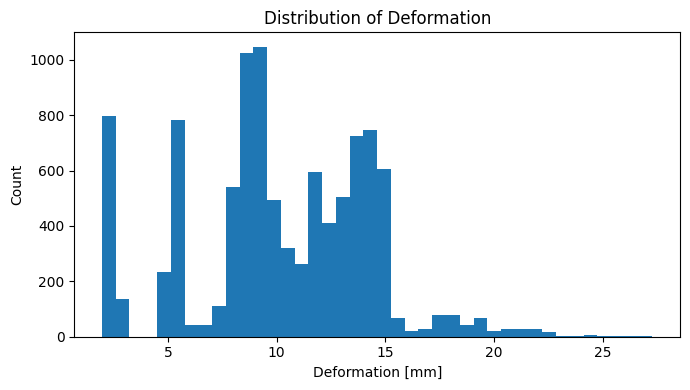


 Stress


,0
count,9931.000000
mean,158.107254
std,46.942677
min,64.791550
25%,126.412651
50%,154.295883
75%,186.874290
max,630.145386


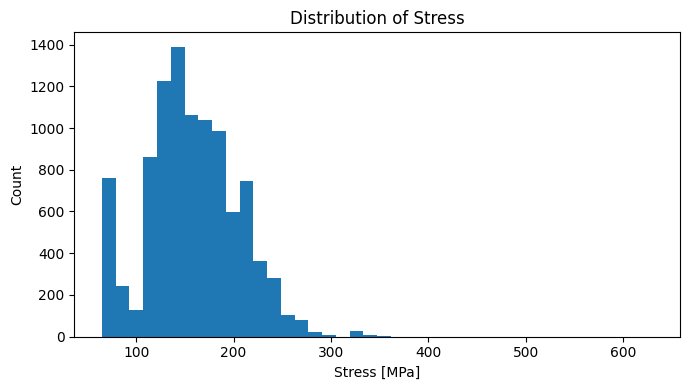


 Mass


,0
count,9931.000000
mean,13.830939
std,1.932757
min,9.544306
25%,12.208798
50%,13.480378
75%,15.649521
max,18.334221


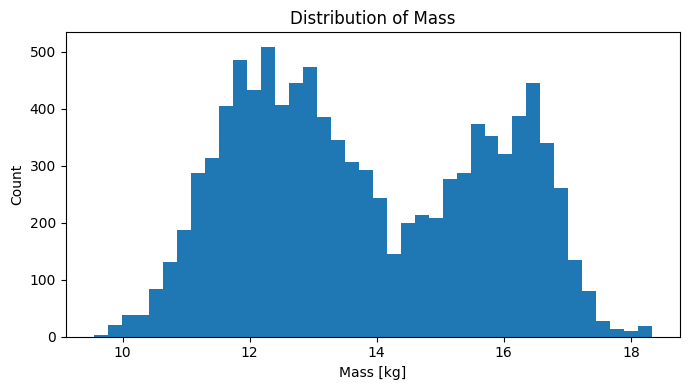

In [ ]:
for name, values, unit in [
    ("Deformation", y_def, "mm"),
    ("Stress", y_stress, "MPa"),
    ("Mass", y_mass, "kg")
]:
    print("\n", name)
    display(pd.Series(values).describe())
    plt.figure(figsize=(7,4))
    plt.hist(values, bins=40)
    plt.xlabel(f"{name} [{unit}]")
    plt.ylabel("Count")
    plt.title(f"Distribution of {name}")
    plt.tight_layout()
    plt.show()

## 4. Parameter statistics and activity

Not all 54 CAD parameters are active for every topology variant. Therefore, zero/non-zero activity is itself informative and is examined separately from parameter magnitude.

,count,mean,std,min,25%,50%,75%,max
P1,9931.0,45.104824,74.926735,0.0,0.0,0.0,143.0,200.0
P2,9931.0,43.330681,74.692139,0.0,0.0,0.0,121.0,240.0
P3,9931.0,30.623100,39.528320,0.0,0.0,0.0,59.0,180.0
P4,9931.0,12.889538,33.382599,0.0,0.0,0.0,0.0,200.0
P5,9931.0,-1.036149,16.064529,-100.0,0.0,0.0,0.0,140.0
P6,9931.0,-1.446682,10.701621,-99.0,0.0,0.0,0.0,40.0
P7,9931.0,21.601048,40.780445,0.0,0.0,0.0,0.0,130.0
P8,9931.0,51.045513,112.923012,0.0,0.0,0.0,0.0,400.0
P9,9931.0,10.834961,32.602394,0.0,0.0,0.0,0.0,130.0
P10,9931.0,0.941698,10.155563,0.0,0.0,0.0,0.0,130.0


,Parameter,Zero_Fraction,Active_Fraction
9,P10,0.991340,0.008660
43,P44,0.990736,0.009264
21,P22,0.922465,0.077535
28,P29,0.922465,0.077535
25,P26,0.922465,0.077535
20,P21,0.922465,0.077535
24,P25,0.922465,0.077535
32,P33,0.922465,0.077535
29,P30,0.922465,0.077535
53,P54,0.921156,0.078844


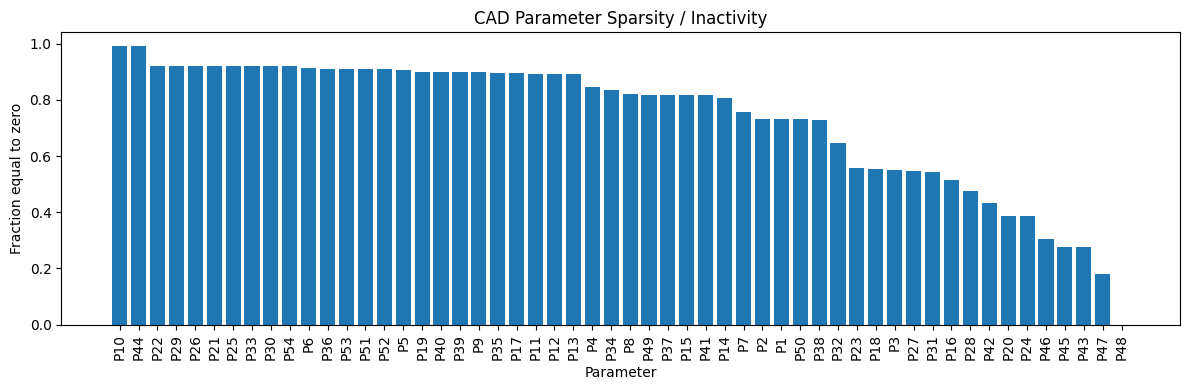

In [ ]:
display(df.describe().T)

activity = pd.DataFrame({
    "Parameter": cols,
    "Zero_Fraction": (df == 0).mean().values,
    "Active_Fraction": (df != 0).mean().values
}).sort_values("Zero_Fraction", ascending=False)

display(activity)

plt.figure(figsize=(12,4))
plt.bar(activity["Parameter"], activity["Zero_Fraction"])
plt.ylabel("Fraction equal to zero")
plt.xlabel("Parameter")
plt.title("CAD Parameter Sparsity / Inactivity")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

### Engineering interpretation
The 54-dimensional vector is not simply a conventional set of continuously varying variables. Different topology variants can activate different subsets. A zero value may therefore contain configuration information in addition to numerical magnitude.

## 5. Parameter correlation with CAE responses

In [ ]:
combined = pd.concat([
    df.reset_index(drop=True),
    pd.DataFrame({"Deformation": y_def, "Stress": y_stress, "Mass": y_mass})
], axis=1)

corr = combined.corr()

for target in ["Deformation", "Stress", "Mass"]:
    s = corr[target].drop(["Deformation","Stress","Mass"], errors="ignore")
    s = s.reindex(s.abs().sort_values(ascending=False).index)
    print(f"\nTop correlations with {target}")
    display(s.head(12).to_frame("Correlation"))


Top correlations with Deformation


,Correlation
P43,0.336317
P45,0.329485
P42,0.280934
P47,-0.221588
P2,-0.130865
P1,-0.122998
P50,-0.110370
P7,-0.104933
P39,0.099760
P28,-0.088149



Top correlations with Stress


,Correlation
P47,0.262576
P14,-0.207072
P12,-0.202909
P13,0.201468
P11,-0.199602
P46,-0.147052
P2,-0.123989
P1,-0.115338
P3,-0.114017
P50,-0.106200



Top correlations with Mass


,Correlation
P46,0.430368
P47,0.425168
P13,0.373914
P12,-0.372555
P11,-0.364432
P7,-0.331251
P54,0.317801
P45,0.260761
P43,0.258682
P48,0.217490


Correlation is used only as a screening tool. A strong correlation does not establish causality because structural response can depend on topology, geometry and interactions between parameters.

# 6. Principal Component Analysis

## Why PCA?
PCA addresses three questions:

1. How many orthogonal directions describe most of the variation in the 54 CAD parameters?
2. Does the low-dimensional parameter space show visible grouping or branches?
3. Which P1–P54 variables contribute most strongly to the dominant directions?

All parameters are standardized first because their numerical ranges differ substantially.

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA()
scores = pca.fit_transform(X_scaled)

explained = pca.explained_variance_ratio_
cumulative = np.cumsum(explained)

pca_summary = pd.DataFrame({
    "PC": np.arange(1, 55),
    "Explained_Variance": explained,
    "Cumulative_Variance": cumulative
})
display(pca_summary)

,PC,Explained_Variance,Cumulative_Variance
0,1,0.186267,0.186267
1,2,0.133243,0.319509
2,3,0.095033,0.414542
3,4,0.082217,0.496759
4,5,0.079047,0.575806
5,6,0.061656,0.637462
6,7,0.052478,0.689940
7,8,0.046421,0.736361
8,9,0.038855,0.775216
9,10,0.037928,0.813144


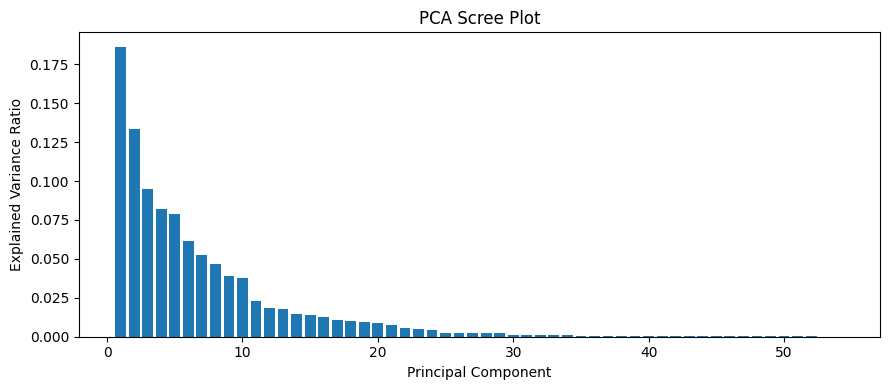

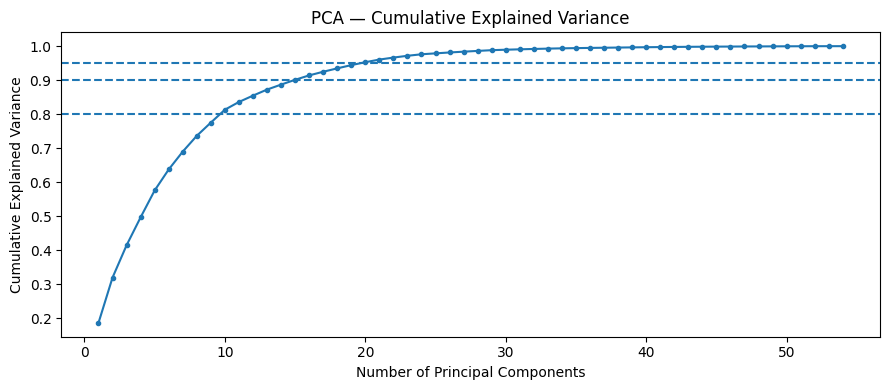

Components required for 80% variance: 10
Components required for 90% variance: 15
Components required for 95% variance: 20


In [ ]:
plt.figure(figsize=(9,4))
plt.bar(np.arange(1,55), explained)
plt.xlabel("Principal Component")
plt.ylabel("Explained Variance Ratio")
plt.title("PCA Scree Plot")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9,4))
plt.plot(np.arange(1,55), cumulative, marker="o", markersize=3)
for threshold in [0.80, 0.90, 0.95]:
    plt.axhline(threshold, linestyle="--")
plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")
plt.tight_layout()
plt.show()

for threshold in [0.80, 0.90, 0.95]:
    n_pc = np.argmax(cumulative >= threshold) + 1
    print(f"Components required for {threshold:.0%} variance: {n_pc}")

### Interpretation
A rapid cumulative-variance rise indicates that much of the 54-dimensional design variation lies along relatively few latent directions. A slower rise indicates a genuinely high-dimensional parameter space.

Because parameter activation is topology-dependent, a principal component may combine **configuration changes and continuous dimensional variation**. The PCs should therefore not be assigned physical CAD names without the original metadata.

## 7. PC1–PC2 maps coloured by FEA response

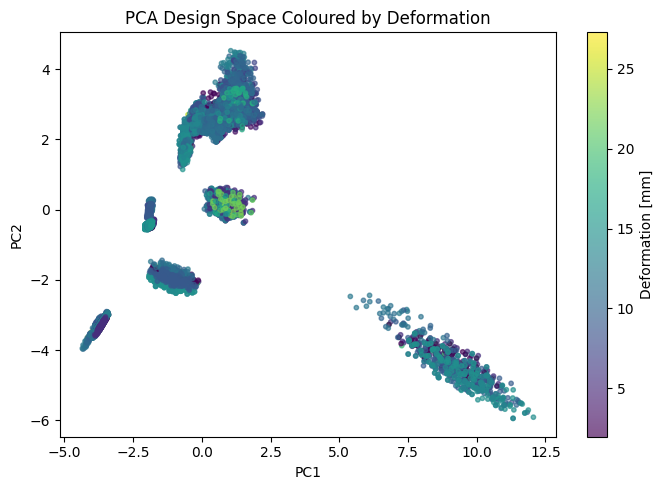

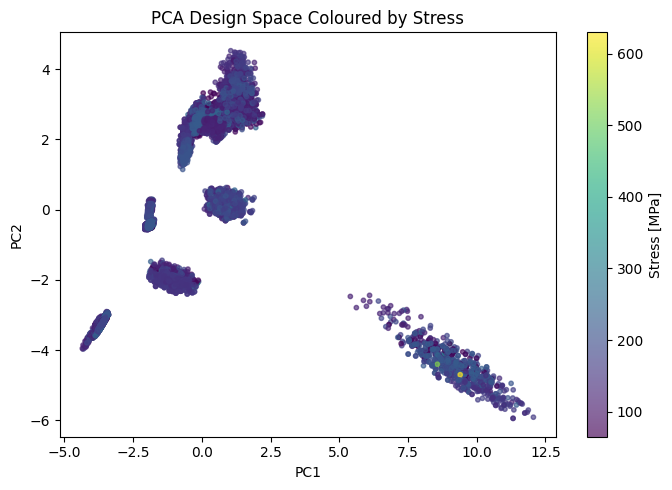

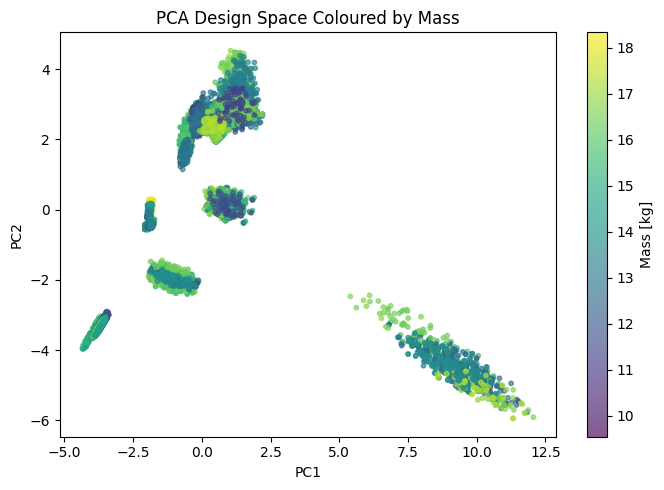

In [ ]:
pc1, pc2 = scores[:,0], scores[:,1]

for name, values, unit in [
    ("Deformation", y_def, "mm"),
    ("Stress", y_stress, "MPa"),
    ("Mass", y_mass, "kg")
]:
    plt.figure(figsize=(7,5))
    sc = plt.scatter(pc1, pc2, c=values, s=10, alpha=0.65)
    plt.xlabel("PC1")
    plt.ylabel("PC2")
    plt.title(f"PCA Design Space Coloured by {name}")
    cb = plt.colorbar(sc)
    cb.set_label(f"{name} [{unit}]")
    plt.tight_layout()
    plt.show()

These are diagnostic plots. Smooth colour gradients indicate systematic response variation through parameter space; separated clouds may indicate configuration structure; large stress differences in the same PCA region would indicate that the 54-parameter projection alone is insufficient for peak-stress prediction.

## 8. PCA loadings

In [ ]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=cols,
    columns=[f"PC{i+1}" for i in range(54)]
)

for pc in ["PC1","PC2","PC3","PC4","PC5"]:
    ranked = loadings[pc].reindex(loadings[pc].abs().sort_values(ascending=False).index)
    print(f"\nTop loadings — {pc}")
    display(ranked.head(10).to_frame("Loading"))


Top loadings — PC1


,Loading
P30,0.263708
P33,0.263178
P21,0.262899
P26,0.262392
P29,0.259149
P22,0.255350
P25,0.253251
P20,0.207041
P24,0.205913
P28,0.205181



Top loadings — PC2


,Loading
P3,0.293187
P1,0.242085
P50,0.238548
P2,0.233847
P37,-0.217630
P41,-0.217230
P15,-0.216048
P49,-0.214970
P38,-0.209151
P28,0.183147



Top loadings — PC3


,Loading
P9,0.392698
P19,0.391440
P40,0.391302
P39,0.390148
P37,-0.204538
P41,-0.204206
P15,-0.202941
P49,-0.202220
P38,-0.200901
P23,0.110770



Top loadings — PC4


,Loading
P52,0.374026
P53,-0.370803
P51,0.353038
P8,0.311671
P1,-0.272711
P2,-0.272696
P50,-0.259919
P48,-0.222861
P16,-0.198578
P4,0.165945



Top loadings — PC5


,Loading
P13,0.437900
P12,-0.437579
P11,-0.433376
P7,-0.359742
P14,-0.286473
P45,-0.253134
P43,-0.252998
P42,-0.186738
P10,-0.123644
P16,0.064768


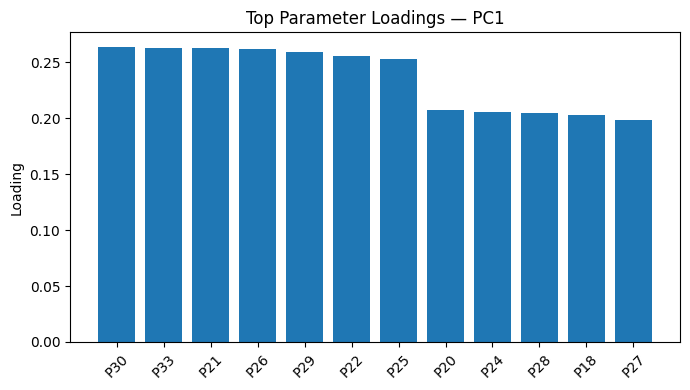

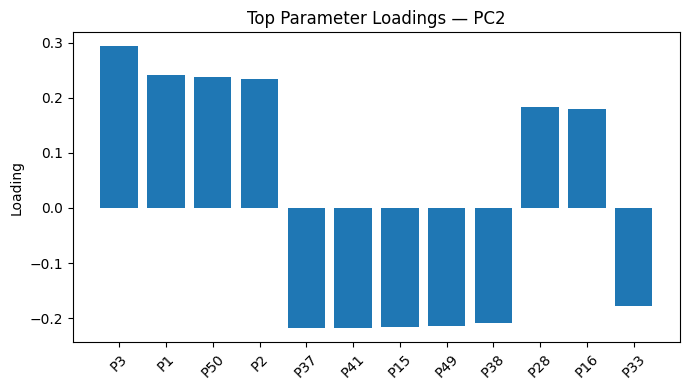

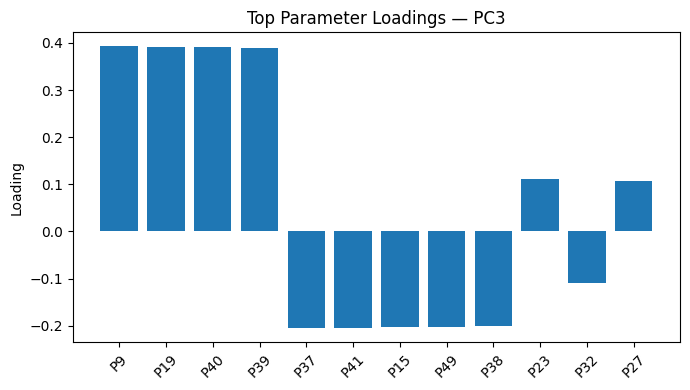

In [ ]:
for pc in ["PC1","PC2","PC3"]:
    ranked = loadings[pc].reindex(
        loadings[pc].abs().sort_values(ascending=False).index
    ).head(12)

    plt.figure(figsize=(7,4))
    plt.bar(ranked.index, ranked.values)
    plt.ylabel("Loading")
    plt.title(f"Top Parameter Loadings — {pc}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

## 9. Parameter activation-pattern analysis

In [ ]:
activation = (X != 0).astype(np.int8)
patterns = np.array(["".join(map(str,row)) for row in activation])
pattern_counts = pd.Series(patterns).value_counts()

print("Unique activation patterns:", len(pattern_counts))
display(pattern_counts.head(20).to_frame("Design_Count"))

Unique activation patterns: 451


,Design_Count
000000000000001000000000000000000000110011101111100000,772
000010000000000110000000000000000010000001101111000000,435
001001010000000100010001000100000001000001101111000000,384
001100010000000000010001000100010000000001101111001110,384
000000000000001000000000000000000000110010000001100000,359
000000000000000001011111111111111100000001101111000000,247
111000000000000101010011001100100000000001101111010000,229
000000001000000001100010001000100000001101101111000000,197
000000000000000101010011001000100100010001101111000000,190
001001010000000100010001000100000001000000000001000000,182


# 10. Clustering the CAD Design Space

The PCA plots revealed several visually distinct regions in the CAD parameter space.
To investigate whether these regions correspond to designs with different structural
behaviour, KMeans clustering was applied.

Clustering was performed on the **full standardized 54-dimensional parameter space**,
rather than only PC1 and PC2. The resulting clusters were then projected onto the
PC1–PC2 plane for visualization.

These clusters are treated as **data-driven design/configuration groups**, not as
ground-truth topology labels.

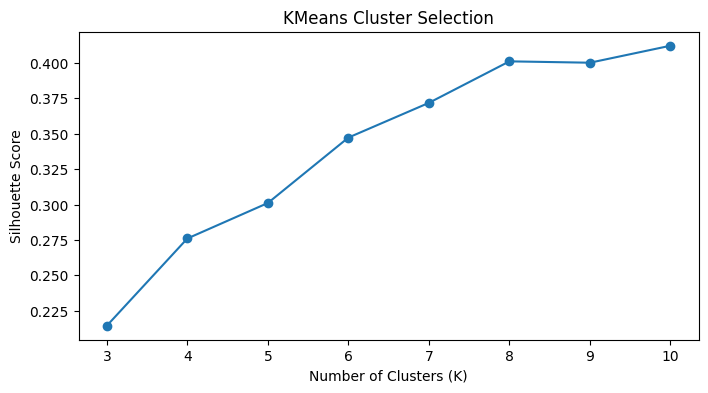

,K,Inertia,Silhouette
0,3,378525.125000,0.214449
1,4,329136.750000,0.276033
2,5,289787.937500,0.301093
3,6,253483.687500,0.347278
4,7,223939.593750,0.371806
5,8,200580.781250,0.401105
6,9,187083.093750,0.400141
7,10,175323.484375,0.412136


In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# Try several cluster counts
k_values = range(3, 11)

inertias = []
silhouettes = []

for k in k_values:
    km = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    labels = km.fit_predict(X_scaled)

    inertias.append(km.inertia_)
    silhouettes.append(
        silhouette_score(X_scaled, labels)
    )

fig, ax = plt.subplots(figsize=(8,4))

ax.plot(k_values, silhouettes, marker="o")
ax.set_xlabel("Number of Clusters (K)")
ax.set_ylabel("Silhouette Score")
ax.set_title("KMeans Cluster Selection")

plt.show()

pd.DataFrame({
    "K": list(k_values),
    "Inertia": inertias,
    "Silhouette": silhouettes
})

In [ ]:
# Change this after examining the previous result
K = 8

kmeans = KMeans(
    n_clusters=K,
    random_state=42,
    n_init=20
)

cluster_labels = kmeans.fit_predict(X_scaled)

print(
    pd.Series(cluster_labels)
      .value_counts()
      .sort_index()
)

0    1000
1    2666
2     908
3    1827
4     875
5     770
6     859
7    1026
Name: count, dtype: int64


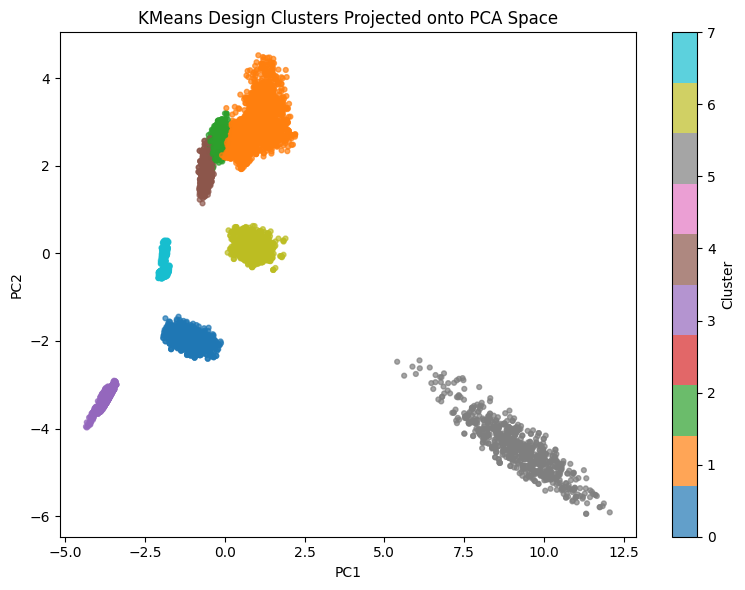

In [ ]:
plt.figure(figsize=(8,6))

scatter = plt.scatter(
    scores[:, 0],
    scores[:, 1],
    c=cluster_labels,
    s=12,
    alpha=0.7,
    cmap="tab10"
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("KMeans Design Clusters Projected onto PCA Space")

plt.colorbar(scatter, label="Cluster")
plt.tight_layout()
plt.show()

In [ ]:
cluster_df = pd.DataFrame({
    "Cluster": cluster_labels,
    "Deformation": y_def,
    "Stress": y_stress,
    "Mass": y_mass
})

cluster_summary = cluster_df.groupby("Cluster").agg(
    N=("Stress", "size"),

    Mean_Deformation=("Deformation", "mean"),
    Std_Deformation=("Deformation", "std"),

    Mean_Stress=("Stress", "mean"),
    Std_Stress=("Stress", "std"),
    Max_Stress=("Stress", "max"),

    Mean_Mass=("Mass", "mean")
)

# High-stress populations
cluster_summary["N_Stress_ge_250"] = (
    cluster_df.assign(flag=cluster_df["Stress"] >= 250)
              .groupby("Cluster")["flag"]
              .sum()
)

cluster_summary["Pct_Stress_ge_250"] = (
    100 * cluster_summary["N_Stress_ge_250"]
    / cluster_summary["N"]
)

cluster_summary["N_Stress_ge_300"] = (
    cluster_df.assign(flag=cluster_df["Stress"] >= 300)
              .groupby("Cluster")["flag"]
              .sum()
)

cluster_summary["Pct_Stress_ge_300"] = (
    100 * cluster_summary["N_Stress_ge_300"]
    / cluster_summary["N"]
)

display(cluster_summary.round(3))

,N,Mean_Deformation,Std_Deformation,Mean_Stress,Std_Stress,Max_Stress,Mean_Mass,N_Stress_ge_250,Pct_Stress_ge_250,N_Stress_ge_300,Pct_Stress_ge_300
Cluster,,,,,,,,,,,
0,1000,10.905,4.427,165.832993,49.592999,352.040009,14.162,34,3.400,31,3.100
1,2666,9.293,3.805,149.229996,45.597000,288.989990,14.283,7,0.263,0,0.000
2,908,10.498,3.609,161.977997,38.506001,346.157990,13.248,4,0.441,2,0.220
3,1827,10.281,4.113,158.388000,51.355999,347.574005,12.985,101,5.528,3,0.164
4,875,10.226,4.933,154.839005,39.403999,233.231003,13.382,0,0.000,0,0.000
5,770,10.400,4.534,166.541000,49.001999,630.145020,14.156,8,1.039,7,0.909
6,859,10.362,4.371,155.516006,45.734001,329.602997,14.396,30,3.492,2,0.233
7,1026,10.478,3.914,168.345993,47.000000,283.209015,14.023,58,5.653,0,0.000


### Engineering interpretation of the CAD-space clusters

KMeans clustering quantitatively confirmed the structured regions observed in the PCA projection.

The eight clusters showed relatively modest differences in mean deformation. Mean deformation ranged only from approximately 9.3 to 10.9 mm across the clusters. This suggests that the CAD configuration groups alone do not divide deformation into sharply separated response regimes.

Stress showed a different behaviour. Although mean stress varied only moderately between clusters, the upper-tail population was highly non-uniform.

Cluster 0 was particularly significant. It contained approximately 10% of the valid designs but 31 of the 45 designs with stress ≥300 MPa — nearly 69% of the extreme-stress population. In contrast, several clusters contained no designs above 300 MPa.

Other clusters exhibited different high-stress characteristics. Cluster 3 and Cluster 7 contained relatively high proportions of designs above 250 MPa, while Cluster 4 contained no designs above 250 MPa. Cluster 5 contained the maximum-stress design in the dataset (~630 MPa), despite having relatively few extreme-stress samples.

These results indicate that extreme stress is associated with particular regions of the CAD design space, but cluster membership alone does not determine stress. Large stress variation remains within individual clusters.

This provided an early indication that peak stress is governed by a hierarchy of design configuration, geometry and parameter interactions rather than by a single smooth global relationship.

**Engineering judgement**: The clustering results suggested that high stress was not randomly distributed throughout the design space. However, because most designs within the high-risk clusters were still not extreme-stress cases, cluster identity alone was insufficient. This motivated deeper investigation of geometry and parameter behaviour within individual design regimes rather than simply training separate models for each KMeans cluster.

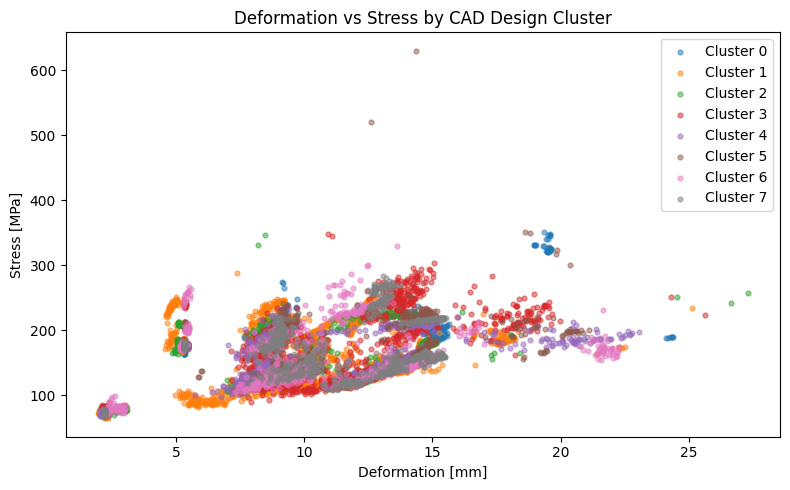

In [ ]:
fig, ax = plt.subplots(figsize=(8,5))

for cluster in sorted(np.unique(cluster_labels)):

    mask = cluster_labels == cluster

    ax.scatter(
        y_def[mask],
        y_stress[mask],
        s=12,
        alpha=0.5,
        label=f"Cluster {cluster}"
    )

ax.set_xlabel("Deformation [mm]")
ax.set_ylabel("Stress [MPa]")
ax.set_title("Deformation vs Stress by CAD Design Cluster")

ax.legend()
plt.tight_layout()
plt.show()

# 11. EDA Conclusions

The exploratory analysis revealed that the CarHoods10k design space is highly structured and that the 54 CAD/topological parameters should not be treated as 54 independent continuous variables.

### 1. The 54-dimensional CAD space contains substantial redundancy

PCA showed that:

- 10 principal components explain approximately 80% of the parameter variance.
- 15 components explain approximately 90%.
- 20 components explain approximately 95%.

This indicates substantial correlation and redundancy among the original CAD variables. However, PCA was retained as an exploratory tool rather than used for dimensionality reduction in the final surrogate models, because low-variance parameter combinations may still influence structural response.

### 2. The CAD design space contains distinct configuration regions

The PC1–PC2 projections revealed several clearly separated regions of the parameter space. Because different topology variants activate different subsets of the 54 CAD parameters, these regions are interpreted as candidate design/configuration regimes rather than confirmed physical topology labels.

KMeans clustering of the full standardized 54-dimensional parameter space supported this observation. An eight-cluster representation was selected as an interpretable exploratory solution after the silhouette score improved substantially up to approximately K=8 and then began to plateau.

### 3. Deformation varies across the design space but is not strongly separated by CAD cluster

Mean deformation across the eight CAD clusters ranged only from approximately 9.3 to 10.9 mm.

This indicates that CAD configuration alone does not divide deformation into sharply separated response regimes. Significant deformation variation remains within each cluster.

This observation supports the later deformation-modeling result: the CAD parameter vector contains useful information, but explicit representation of the resulting physical geometry is required for high prediction accuracy.

### 4. Extreme stress is strongly associated with particular regions of the CAD space

Stress exhibited substantially stronger regime dependence than deformation.

Cluster 0 contained approximately 10% of the valid designs but 31 of the 45 designs with stress ≥300 MPa — nearly 69% of the entire extreme-stress population.

Other clusters exhibited distinctly different tail behaviour:

- Cluster 4 contained no designs above 250 MPa.
- Clusters 3 and 7 contained relatively high proportions of designs above 250 MPa.
- Cluster 5 contained the maximum-stress design (~630 MPa), despite containing relatively few ≥300 MPa cases.

Therefore, high-stress designs are not randomly distributed throughout the CAD design space.

### 5. CAD cluster membership alone cannot predict peak stress

Although extreme stress was concentrated in particular clusters, large stress variation remained within individual clusters.

Most designs belonging to the high-risk clusters were not themselves extreme-stress cases.

This suggests that peak stress cannot be explained by configuration membership alone. Additional information about the resulting geometry and parameter magnitudes/interactions is required.

### 6. The EDA suggested different modeling strategies for deformation and stress

The combined PCA and clustering analysis provided an early indication that deformation and stress are fundamentally different surrogate-learning problems.

For deformation, global geometry and overall design characteristics appear to dominate the response. This motivated the multimodal combination of CAD parameters, engineered geometry descriptors and learned point-cloud features.

For stress, the concentration of extreme responses within particular design regions, combined with substantial within-region variation, suggested a more hierarchical relationship:

**Design configuration → geometry regime → parameter magnitude/interactions → stress**

This observation later became an important motivation for investigating design families and ultimately developing the regime-aware Mixture-of-Experts stress surrogate.

---

## Engineering takeaway

The EDA changed the modeling strategy rather than simply describing the dataset.

PCA revealed a structured and partially lower-dimensional CAD design space. Clustering showed that these design regions alone were insufficient to explain deformation, while extreme stress was strongly concentrated in particular regions but still varied substantially within them.

These findings motivated two different modeling directions:

**Deformation:** explicitly combine CAD parameters with physical 3D geometry.

**Stress:** investigate design and geometry regimes before selecting the final regression architecture.